In [ ]:
import torch
from torch import nn
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from d2l import torch as d2l
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

c:\Users\21799\anaconda3\envs\pytorch\lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


导入数据库，乳腺癌数据


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\21799\.cache\kagglehub\datasets\awsaf49\cbis-ddsm-breast-cancer-image-dataset\versions\1


In [ ]:
import pandas as pd
import os

csv_dir = os.path.join(path, 'csv')
 
meta       = pd.read_csv(os.path.join(csv_dir, 'meta.csv'))
dicom_info = pd.read_csv(os.path.join(csv_dir, 'dicom_info.csv'))

mass_train = pd.read_csv(os.path.join(csv_dir, 'mass_case_description_train_set.csv'))
mass_test  = pd.read_csv(os.path.join(csv_dir, 'mass_case_description_test_set.csv'))
calc_train = pd.read_csv(os.path.join(csv_dir, 'calc_case_description_train_set.csv'))
calc_test  = pd.read_csv(os.path.join(csv_dir, 'calc_case_description_test_set.csv'))

print("meta shape:      ", meta.shape)
print("dicom_info shape:", dicom_info.shape)
print("mass_train shape:", mass_train.shape)
print("mass_test shape: ", mass_test.shape)
print("calc_train shape:", calc_train.shape
      )
print("calc_test shape: ", calc_test.shape)

mass_train.head()


meta shape:       (6775, 9)
dicom_info shape: (10237, 38)
mass_train shape: (1318, 14)
mass_test shape:  (378, 14)
calc_train shape: (1546, 14)
calc_test shape:  (326, 14)


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [ ]:


jpeg_dir = os.path.join(path, 'jpeg')

def get_jpeg_path(file_path_col_value):

  
    parts = file_path_col_value.strip().split('/')
    if len(parts) >= 2:
        series_uid = parts[-2]
        filename   = os.path.splitext(parts[-1])[0] + '.jpg'
        candidates = []
        series_path = os.path.join(jpeg_dir, series_uid)
        if os.path.isdir(series_path):
            imgs = [f for f in os.listdir(series_path) if f.endswith('.jpg')]
            if imgs:
                candidates = [os.path.join(series_path, imgs[0])]
        return candidates[0] if candidates else None
    return None

mass_train['full_image_path'] = mass_train['image file path'].apply(get_jpeg_path)

matched = mass_train['full_image_path'].notna().sum()
print(f"mass_train : {matched} / {len(mass_train)}")
print(mass_train[['patient_id', 'pathology', 'full_image_path']].head())


mass_train 中成功匹配到图片: 1318 / 1318
  patient_id  pathology                                    full_image_path
0    P_00001  MALIGNANT  C:\Users\21799\.cache\kagglehub\datasets\awsaf...
1    P_00001  MALIGNANT  C:\Users\21799\.cache\kagglehub\datasets\awsaf...
2    P_00004     BENIGN  C:\Users\21799\.cache\kagglehub\datasets\awsaf...
3    P_00004     BENIGN  C:\Users\21799\.cache\kagglehub\datasets\awsaf...
4    P_00004     BENIGN  C:\Users\21799\.cache\kagglehub\datasets\awsaf...


C:\Users\21799\AppData\Local\Temp\ipykernel_22252\1075992391.py:13: UserWarning: Glyph 20083 (\N{CJK UNIFIED IDEOGRAPH-4E73}) missing from current font.
  plt.tight_layout()
C:\Users\21799\AppData\Local\Temp\ipykernel_22252\1075992391.py:13: UserWarning: Glyph 33146 (\N{CJK UNIFIED IDEOGRAPH-817A}) missing from current font.
  plt.tight_layout()
C:\Users\21799\AppData\Local\Temp\ipykernel_22252\1075992391.py:13: UserWarning: Glyph 30284 (\N{CJK UNIFIED IDEOGRAPH-764C}) missing from current font.
  plt.tight_layout()
C:\Users\21799\AppData\Local\Temp\ipykernel_22252\1075992391.py:13: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from current font.
  plt.tight_layout()
C:\Users\21799\AppData\Local\Temp\ipykernel_22252\1075992391.py:13: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from current font.
  plt.tight_layout()
C:\Users\21799\AppData\Local\Temp\ipykernel_22252\1075992391.py:13: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) miss

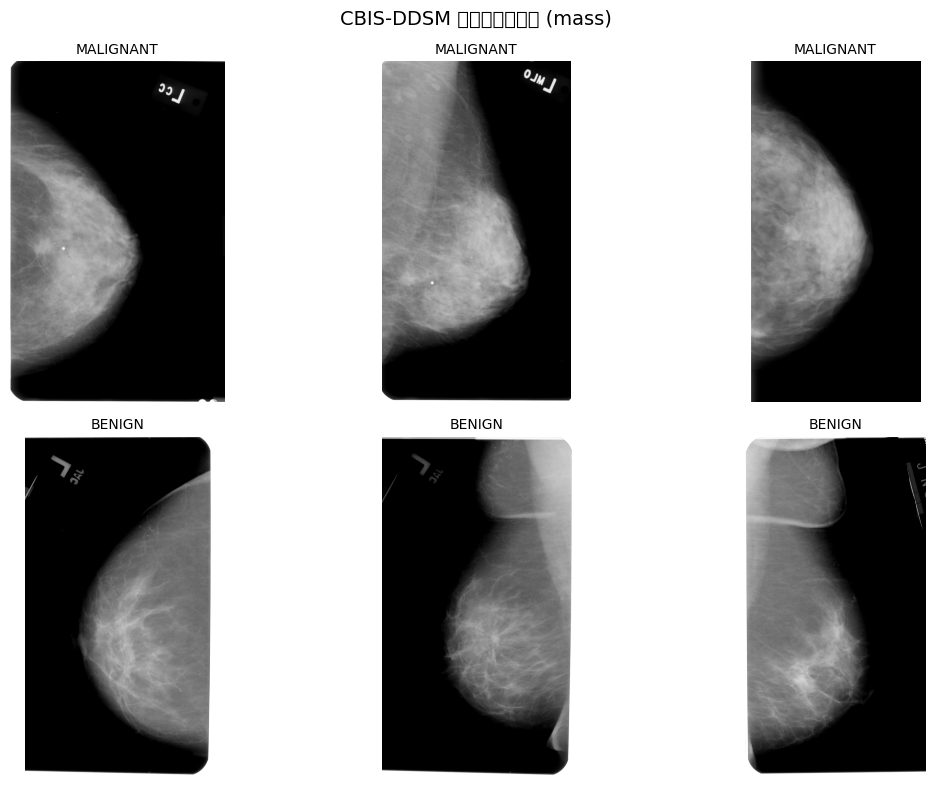

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('CBIS-DDSM 乳腺癌样例图片 (mass)', fontsize=14)

for i, label in enumerate(['MALIGNANT', 'BENIGN']):
    samples = mass_train[mass_train['pathology'] == label]['full_image_path'].dropna().head(3).tolist()
    for j, img_path in enumerate(samples):
        img = mpimg.imread(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(label, fontsize=10)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
from torchvision import models
import torch.nn as nn

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

In [ ]:
in_features = model.fc.in_features  # 2048
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 2)
)

In [ ]:


# ── 1. 标签编码（不依赖 sklearn） ────────────────────────────────────────────
df = mass_train[mass_train['pathology'].isin(['MALIGNANT', 'BENIGN'])].dropna(subset=['full_image_path']).copy()
df['label'] = (df['pathology'] == 'MALIGNANT').astype(int)   # MALIGNANT=1, BENIGN=0
df = df.reset_index(drop=True)

# 手动 8:2 分层划分
np.random.seed(42)
train_idx, val_idx = [], []
for lbl in [0, 1]:
    idx = df[df['label'] == lbl].index.tolist()
    np.random.shuffle(idx)
    cut = int(len(idx) * 0.8)
    train_idx += idx[:cut]
    val_idx   += idx[cut:]

train_df = df.loc[train_idx].reset_index(drop=True)
val_df   = df.loc[val_idx].reset_index(drop=True)
print(f"训练集: {len(train_df)}  验证集: {len(val_df)}")
print(f"训练集标签分布:\n{train_df['label'].value_counts()}")

# ── 2. Dataset & DataLoader ──────────────────────────────────────────────────
class BreastCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, 'full_image_path']).convert('RGB')
        label = int(self.df.loc[idx, 'label'])
        if self.transform:
            img = self.transform(img)
        return img, label

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_loader = DataLoader(BreastCancerDataset(train_df, train_transform), batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(BreastCancerDataset(val_df,   val_transform),   batch_size=32, shuffle=False, num_workers=0)

# ── 3. 训练设置 ──────────────────────────────────────────────────────────────
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n使用设备: {device}")

model     = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# ── 4. 训练循环 ──────────────────────────────────────────────────────────────
NUM_EPOCHS = 10

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

print(f"\n{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>10}  {'Val Loss':>9}  {'Val Acc':>8}")
print('-' * 55)

best_val_acc = 0.0
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()

    marker = ' *' if vl_acc > best_val_acc else ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_resnet50_breast.pth')
    print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc:>10.4f}  {vl_loss:>9.4f}  {vl_acc:>8.4f}{marker}")

print(f"\n训练完成！最优验证准确率: {best_val_acc:.4f}")
print("最优模型已保存至 best_resnet50_breast.pth")


训练集: 970  验证集: 244
训练集标签分布:
label
1    509
0    461
Name: count, dtype: int64

使用设备: cuda

 Epoch  Train Loss   Train Acc   Val Loss   Val Acc
-------------------------------------------------------
     1      0.7057      0.5454     0.6742    0.5820 *
     2      0.6983      0.5753     0.6339    0.6270 *
     3      0.6639      0.6175     0.6283    0.6230
     4      0.6381      0.6577     0.8629    0.5287
     5      0.6279      0.6608     0.6166    0.6352 *
     6      0.5660      0.7021     0.6410    0.6598 *
     7      0.5509      0.7186     0.5582    0.6967 *
     8      0.5105      0.7598     0.5893    0.6844


KeyboardInterrupt: 